# Trying different class4 classification methods

In [759]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys

from pathlib import Path



# Own functions
# Necessary to import from src dir
sys.path.append("../..")
import src.preprocessing_minimal as ppm

## Reading in the data

In [760]:


data_dir = Path('../data')
output_dir = Path('../outputs')

train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
final_test_df = pd.read_csv(data_dir / 'test.csv').drop(columns=["partlybad", "date"])

In [761]:
X_train, y_train2, y_train4 = ppm.split_xy(train_df)

In [762]:
y_train4.value_counts()

class4
nonevent    225
II          117
Ib           82
Ia           26
Name: count, dtype: int64

## Scaling the data

In [763]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

## Random forest classifier

In [764]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

multi_accuracies = []
rf_model = RandomForestClassifier(n_estimators=160, random_state=42, n_jobs=-1)
for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
    y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
    rf_model.fit(X_train_fold, y_train_fold)
    
    y_pred_fold = rf_model.predict(X_test_fold)

    multiclass_accuracy = accuracy_score(y_test_fold, y_pred_fold)
    multi_accuracies.append(multiclass_accuracy)

print(f"Average Accuracy: {np.mean(multi_accuracies):.4f}")

Average Accuracy: 0.6533


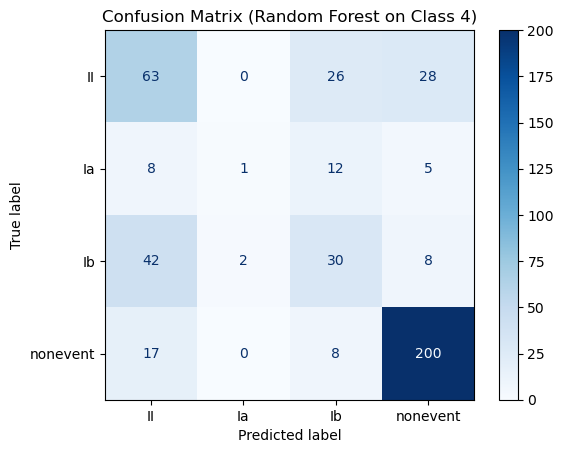

In [765]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf_model = RandomForestClassifier(n_estimators=160, random_state=42, n_jobs=-1)
all_preds = []
all_true = []

for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
    y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
    rf_model.fit(X_train_fold, y_train_fold)
    all_preds.extend(rf_model.predict(X_test_fold))
    all_true.extend(y_test_fold)

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (Random Forest on Class 4)")
plt.show()

## SVM with PCA

In [766]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

multi_accuracies_svm = []
for n in range(1, 30):
    multi_accuracies_n = []
    #pca = PCA(n_components=n)
    svm = SVC(kernel='rbf')#, random_state=42)
    for train_index, test_index in skf.split(X_train_scaled, y_train4):
        '''
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_train_pca = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])], index=X_train_scaled.index)
        X_train_fold, X_test_fold = X_train_pca.iloc[train_index], X_train_pca.iloc[test_index]
        y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
        '''
        X_train_fold = X_train_scaled.iloc[train_index]
        X_test_fold  = X_train_scaled.iloc[test_index]
        y_train_fold = y_train4.iloc[train_index]
        y_test_fold  = y_train4.iloc[test_index]
        
        # Fit PCA on train fold only, transform both
        pca = PCA(n_components=n)
        X_train_pca = pca.fit_transform(X_train_fold)
        X_test_pca  = pca.transform(X_test_fold)

        #svm.fit(X_train_fold, y_train_fold.values.ravel())
        #accuracy = svm.score(X_test_fold, y_test_fold)
        svm.fit(X_train_pca, y_train_fold.values.ravel())
        accuracy = svm.score(X_test_pca, y_test_fold)
        multi_accuracies_n.append(accuracy)
    multi_accuracies_svm.append(np.mean(multi_accuracies_n))

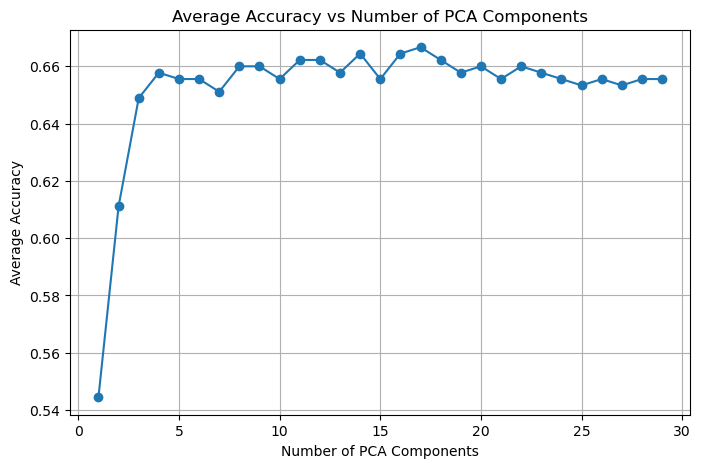

In [767]:
# Plotting the accuracy against number of PCA components
plt.figure(figsize=(8, 5))
plt.plot(range(1, 30), multi_accuracies_svm, marker='o')
plt.title('Average Accuracy vs Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Average Accuracy')
plt.grid()
plt.show()

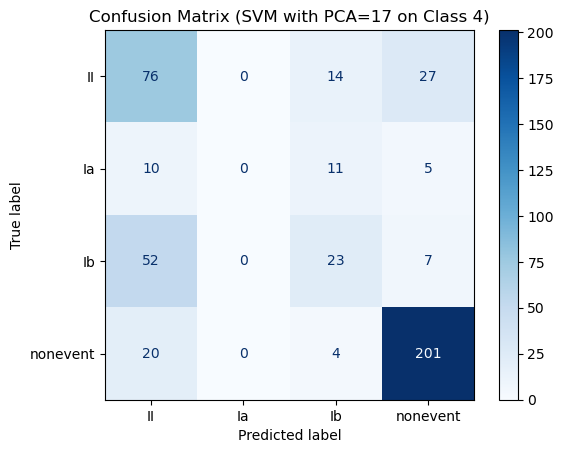

In [768]:
#Confusion matrix for best PCA component number
best_n = np.argmax(multi_accuracies_svm) + 1
svm = SVC(kernel='rbf')
all_preds = []
all_true = []
pca = PCA(n_components=best_n)
for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold = X_train_scaled.iloc[train_index]
    X_test_fold  = X_train_scaled.iloc[test_index]
    y_train_fold = y_train4.iloc[train_index]
    y_test_fold  = y_train4.iloc[test_index]
    
    # Fit PCA on train fold only, transform both
    pca.fit(X_train_fold)
    X_train_pca = pca.transform(X_train_fold)
    X_test_pca  = pca.transform(X_test_fold)

    svm.fit(X_train_pca, y_train_fold.values.ravel())
    all_preds.extend(svm.predict(X_test_pca))
    all_true.extend(y_test_fold)
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (SVM with PCA={best_n} on Class 4)")
plt.show()

## SVM PCA including testing set

This might perform better in the kaggle scoring. In theory PCA learns the test set structure.

In [769]:
X_test_final = pd.read_csv(data_dir / 'test.csv').drop(columns=["partlybad", "date", "id"])
X_test_final = scaler.transform(X_test_final)
#X_test_final = X_test_final.drop(columns=to_drop)


In [770]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

multi_accuracies_svm = []
for n in range(1, 21):
    multi_accuracies_n = []
    svm = SVC(kernel='rbf')#, random_state=42)
    for train_index, test_index in skf.split(X_train_scaled, y_train4):
        '''
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_train_pca = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])], index=X_train_scaled.index)
        X_train_fold, X_test_fold = X_train_pca.iloc[train_index], X_train_pca.iloc[test_index]
        y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
        '''
        X_train_fold = X_train_scaled.iloc[train_index]
        X_train_pca_fold = pd.concat([X_train_fold, X_test_final], axis=0)
        assert list(X_train_fold.columns) == list(X_test_final.columns), "Column mismatch!"
        X_test_fold  = X_train_scaled.iloc[test_index]
        y_train_fold = y_train4.iloc[train_index]
        y_test_fold  = y_train4.iloc[test_index]
        # Fit PCA on train fold only, transform both
        pca = PCA(n_components=n)
        pca.fit(X_train_pca_fold)
        X_train_pca = pca.transform(X_train_fold)
        X_test_pca  = pca.transform(X_test_fold)

        #svm.fit(X_train_fold, y_train_fold.values.ravel())
        #accuracy = svm.score(X_test_fold, y_test_fold)
        svm.fit(X_train_pca, y_train_fold.values.ravel())
        accuracy = svm.score(X_test_pca, y_test_fold)
        multi_accuracies_n.append(accuracy)
    multi_accuracies_svm.append(np.mean(multi_accuracies_n))

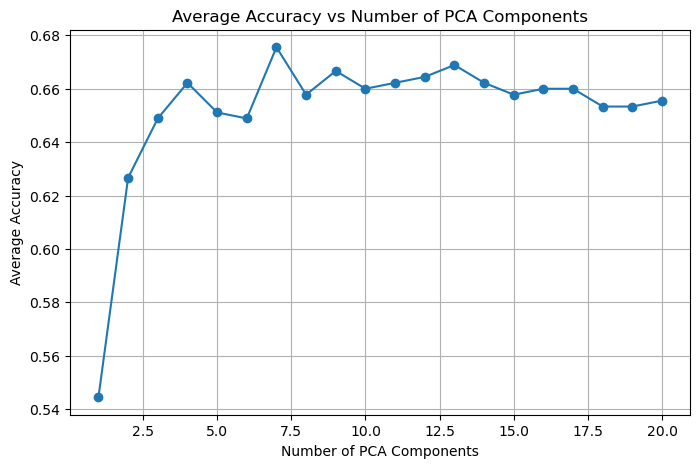

In [771]:
# Plotting the accuracy against number of PCA components
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), multi_accuracies_svm, marker='o')
plt.title('Average Accuracy vs Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Average Accuracy')
plt.grid()
plt.show()

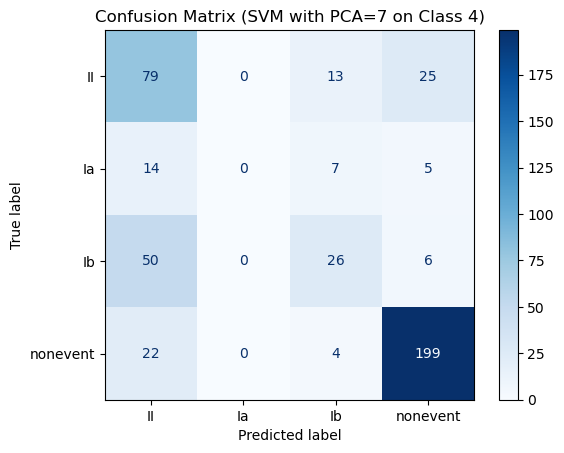

In [772]:
#confusion matrix for best PCA component number
best_n = np.argmax(multi_accuracies_svm) + 1
svm = SVC(kernel='rbf')
all_preds = []
all_true = []
pca = PCA(n_components=best_n)
for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold = X_train_scaled.iloc[train_index]
    X_train_pca_fold = pd.concat([X_train_fold, X_test_final], axis=0)
    assert list(X_train_fold.columns) == list(X_test_final.columns), "Column mismatch!"
    X_test_fold  = X_train_scaled.iloc[test_index]
    y_train_fold = y_train4.iloc[train_index]
    y_test_fold  = y_train4.iloc[test_index]
    
    # Fit PCA on train fold only, transform both
    pca.fit(X_train_pca_fold)
    X_train_pca = pca.transform(X_train_fold)
    X_test_pca  = pca.transform(X_test_fold)

    svm.fit(X_train_pca, y_train_fold.values.ravel())
    all_preds.extend(svm.predict(X_test_pca))
    all_true.extend(y_test_fold)
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (SVM with PCA={best_n} on Class 4)")
plt.show()

## First class2 logarithmic regression and then other method for the event classes.

First training a random forest with only events:

In [773]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

#Separating only true events
event_indices = y_train4[y_train4 != 'nonevent' ].index
X_train_events = X_train_scaled.iloc[event_indices]
y3_train = y_train4.iloc[event_indices]


skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

multi_accuracies = []
rf_model = RandomForestClassifier(n_estimators=160, random_state=42, n_jobs=-1)
for train_index, test_index in skf.split(X_train_events, y3_train):
    X_train_fold, X_test_fold = X_train_events.iloc[train_index], X_train_events.iloc[test_index]
    y_train_fold, y_test_fold = y3_train.iloc[train_index], y3_train.iloc[test_index]
    rf_model.fit(X_train_fold, y_train_fold)
    
    y_pred_fold = rf_model.predict(X_test_fold)

    multiclass_accuracy = accuracy_score(y_test_fold, y_pred_fold)
    multi_accuracies.append(multiclass_accuracy)

print(f"Average Accuracy: {np.mean(multi_accuracies):.4f}")

Average Accuracy: 0.5391


In [774]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
binary_accuracies = []
event_type_accuracies = []
final_accuracies = []
log_model = LogisticRegression(C=0.28, l1_ratio=1, solver='liblinear', max_iter=1000)
rf_model = RandomForestClassifier(n_estimators=160, random_state=42, n_jobs=-1, class_weight='balanced')

for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
    y2_train_fold, y2_test_fold = y_train2.iloc[train_index], y_train2.iloc[test_index]
    y4_train_fold, y4_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]

    log_model.fit(X_train_fold, y2_train_fold)
    y2_pred = log_model.predict(X_test_fold)
    binary_accuracies.append(accuracy_score(y2_test_fold, y2_pred))

    # Subset to true events only
    event_indices_train = np.where(y4_train_fold != 'nonevent')[0]
    event_indices_test  = np.where(y4_test_fold  != 'nonevent')[0]
    X3_train_fold = X_train_fold.iloc[event_indices_train]
    x3_test_fold  = X_test_fold.iloc[event_indices_test]
    y3_train_fold = y4_train_fold.iloc[event_indices_train]
    y3_test_fold  = y4_test_fold.iloc[event_indices_test]

    # Train RF and evaluate on true events
    rf_model.fit(X3_train_fold, y3_train_fold)
    y3_pred_test = rf_model.predict(x3_test_fold)
    event_type_accuracies.append(accuracy_score(y3_test_fold, y3_pred_test))

    # Predict event types for logistic model's predicted events
    event_indices_pred = np.where(y2_pred == 'event')[0]
    x3_pred_fold = X_test_fold.iloc[event_indices_pred]
    y3_pred = rf_model.predict(x3_pred_fold)

    # Combine predictions
    final_predictions = np.full(len(y2_pred), 'nonevent', dtype=object)
    event_mask = (y2_pred == 'event')
    final_predictions[event_mask] = y3_pred
    final_accuracies.append(accuracy_score(y4_test_fold, final_predictions))

print(f"Average Binary Accuracy: {np.mean(binary_accuracies):.4f}")
print(f"Average Event Type Accuracy: {np.mean(event_type_accuracies):.4f}")
print(f"Average Final Accuracy: {np.mean(final_accuracies):.4f}")

Average Binary Accuracy: 0.8911
Average Event Type Accuracy: 0.5255
Average Final Accuracy: 0.6667


### Same, but with logreg + SVM with PCA

In [821]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

skf = StratifiedKFold(n_splits=10, shuffle=True)#, random_state=42)
binary_accuracies = []
event_type_accuracies = []
final_accuracies = []

log_model = LogisticRegression(C=0.28, l1_ratio=1, solver='liblinear', max_iter=1000)
svm_model = SVC(kernel='rbf')#, class_weight='balanced')

for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
    y2_train_fold, y2_test_fold = y_train2.iloc[train_index], y_train2.iloc[test_index]
    y4_train_fold, y4_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]

    # First filtering by event vs nonevent
    event_indices_train = np.where(y4_train_fold != 'nonevent')[0]
    event_indices_test = np.where(y4_test_fold != 'nonevent')[0]
    X3_train_fold = X_train_fold.iloc[event_indices_train]
    x3_test_fold  = X_test_fold.iloc[event_indices_test]
    y3_train_fold = y4_train_fold.iloc[event_indices_train]
    y3_test_fold  = y4_test_fold.iloc[event_indices_test]

    # Fit PCA on event train fold only, transform both
    pca = PCA(n_components=8)
    pca.fit(X3_train_fold)
    X3_train_pca = pca.transform(X3_train_fold)
    x3_test_pca  = pca.transform(x3_test_fold)
    x_test_pca = pca.transform(X_test_fold)
    # Train SVM and evaluate on true events
    svm_model.fit(X3_train_pca, y3_train_fold)

    #Fit SVM to whole data
    svm_pred = svm_model.predict(x_test_pca)
    
    #Training logistic regression for event vs nonevent classification
    log_model.fit(X_train_fold, y2_train_fold)
    y2_pred = log_model.predict(X_test_fold)
    y2_pred_prob = log_model.predict_proba(X_test_fold)[:, 0]

    #Combining the predictions from svm and probabilities from logistic regression
    combined_df = pd.DataFrame({
        'svm_pred': svm_pred,
        'log_pred': y2_pred,
        'log_prob': y2_pred_prob,
        'true_label': y4_test_fold,
        'true_bin_label': y2_test_fold
    })
    #Mapping svm prediction to nonevent if logprob is < 0.5
    combined_df['final_pred'] = combined_df.apply(lambda row: row['svm_pred'] if row['log_pred'] == 'event' else 'nonevent', axis=1)
    comb_df_events = combined_df[combined_df['true_bin_label'] == 'event']
    # Train SVM and evaluate on true events
    binary_accuracies.append(accuracy_score(combined_df['true_bin_label'], combined_df['log_pred']))
    event_type_accuracies.append(accuracy_score(comb_df_events['true_label'], comb_df_events['svm_pred']))
    final_accuracies.append(accuracy_score(combined_df['true_label'], combined_df['final_pred']))


print(f"Average Binary Accuracy: {np.mean(binary_accuracies):.4f}")
print(f"Average Event Type Accuracy: {np.mean(event_type_accuracies):.4f}")
print(f"Average Final Accuracy: {np.mean(final_accuracies):.4f}")

Average Binary Accuracy: 0.8978
Average Event Type Accuracy: 0.5466
Average Final Accuracy: 0.6822


## Combinig two logistic regression models (No class Ib classification)

In [899]:
from sklearn.linear_model import LogisticRegression

train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
X_train, y_train2, y_train4 = ppm.split_xy(train_df)
scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)

skf = StratifiedKFold(n_splits=5, shuffle=True)
binary_accuracies = []
II_IB_accuracies = []
final_accuracies = []
log_model1 = LogisticRegression(C=0.28, l1_ratio=1, solver='liblinear', max_iter=1000)
log_model2 = LogisticRegression(C=0.17, l1_ratio=1, solver='liblinear', max_iter=1000)

for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
    y2_train_fold, y2_test_fold = y_train2.iloc[train_index], y_train2.iloc[test_index]
    y4_train_fold, y4_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]

    log_model1.fit(X_train_fold, y2_train_fold)
    y2_pred = log_model1.predict(X_test_fold)
    y2_pred_prob = log_model1.predict_proba(X_test_fold)[:, 0]

    # Subset to true events only
    event_indices_train = np.where(y4_train_fold != 'nonevent')[0]
    event_indices_test  = np.where(y4_test_fold  != 'nonevent')[0]

    #event_indices_train = np.where((y4_train_fold != 'nonevent') & (y4_train_fold != 'Ib'))[0]
    #event_indices_test  = np.where((y4_test_fold  != 'nonevent') & (y4_test_fold  != 'Ib'))[0]
    event_scaler = StandardScaler().set_output(transform="pandas")
    event_scaler.fit(X_train_fold.iloc[event_indices_train])
    Xev_train_fold = event_scaler.transform(X_train_fold.iloc[event_indices_train])
    xev_test_fold  = event_scaler.transform(X_test_fold.iloc[event_indices_test])
    yev_train_fold = y4_train_fold.iloc[event_indices_train].replace({'Ia': 'Ib'})
    yev_test_fold  = y4_test_fold.iloc[event_indices_test]

    # Train log2 and evaluate on true events
    log_model2.fit(Xev_train_fold, yev_train_fold)
    yev_test_pred = log_model2.predict(xev_test_fold)
    II_IB_accuracies.append(accuracy_score(yev_test_fold, yev_test_pred))

    # Predict event types for logistic model's predicted events
    event_indices_pred = np.where(y2_pred == 'event')[0]
    xev_pred_fold = X_test_fold.iloc[event_indices_pred]
    xev_pred_fold = event_scaler.transform(xev_pred_fold)
    yev_pred = log_model2.predict(xev_pred_fold)
    # Initialize with 'nonevent' for all rows
    yev_pred_full = np.full(len(y2_pred), 'nonevent', dtype=object)
    # Fill in model2's predictions only where model1 predicted 'event'
    yev_pred_full[event_indices_pred] = yev_pred

    #Combining the predictions from svm and probabilities from logistic regression
    combined_df = pd.DataFrame({
        'log1_pred': y2_pred,
        'true_bin_label': y2_test_fold,
        'log_prob': y2_pred_prob,
        'log2_pred': yev_pred_full,
        'true_label': y4_test_fold,
    })
    binary_accuracies.append(accuracy_score(combined_df['true_bin_label'], combined_df['log1_pred']))
    final_accuracies.append(accuracy_score(combined_df['true_label'], combined_df['log2_pred']))
    
print(f"Average Binary Accuracy: {np.mean(binary_accuracies):.4f}")
print(f"Average event class Accuracy: {np.mean(II_IB_accuracies):.4f}")
print(f"Average Final Accuracy: {np.mean(final_accuracies):.4f}")

Average Binary Accuracy: 0.8889
Average event class Accuracy: 0.5644
Average Final Accuracy: 0.6889


In [900]:
# Calculate perplexity for logistic regression
from sklearn.metrics import log_loss
perplexity = np.exp(log_loss(combined_df['true_bin_label'], 1- combined_df['log_prob']))
print(f"Perplexity: {perplexity:.4f}")
est_score = 1/3 * (np.mean(binary_accuracies) + np.mean(final_accuracies) + np.max([0.0, np.min([1.0, 2.0 - perplexity])]))
print(f"Estimated Score: {est_score:.4f}")

Perplexity: 1.3768
Estimated Score: 0.7337


## Same but include test set in PCA

In [890]:
X_test_final = pd.read_csv(data_dir / 'test.csv').drop(columns=["partlybad", "date", "id"])
X_test_final_scaled = scaler.transform(X_test_final)

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
binary_accuracies = []
event_type_accuracies = []
final_accuracies = []

log_model = LogisticRegression(C=0.28, l1_ratio=1, solver='liblinear', max_iter=1000)
svm_model = SVC(kernel='rbf')#, class_weight='balanced')

for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
    y2_train_fold, y2_test_fold = y_train2.iloc[train_index], y_train2.iloc[test_index]
    y4_train_fold, y4_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]

    # First filtering by event vs nonevent
    event_indices_train = np.where(y4_train_fold != 'nonevent')[0]
    event_indices_test = np.where(y4_test_fold != 'nonevent')[0]
    X3_train_fold = X_train_fold.iloc[event_indices_train]
    x3_test_fold  = X_test_fold.iloc[event_indices_test]
    y3_train_fold = y4_train_fold.iloc[event_indices_train]
    y3_test_fold  = y4_test_fold.iloc[event_indices_test]

    # Fit PCA on event train fold only, transform both
    pca = PCA(n_components=8)
    pca.fit(pd.concat([X3_train_fold, X_test_final_scaled]))
    X3_train_pca = pca.transform(X3_train_fold)
    x3_test_pca  = pca.transform(x3_test_fold)
    x_test_pca = pca.transform(X_test_fold)
    # Train SVM and evaluate on true events
    svm_model.fit(X3_train_pca, y3_train_fold)

    #Fit SVM to whole data
    svm_pred = svm_model.predict(x_test_pca)
    
    #Training logistic regression for event vs nonevent classification
    log_model.fit(X_train_fold, y2_train_fold)
    y2_pred = log_model.predict(X_test_fold)
    y2_pred_prob = log_model.predict_proba(X_test_fold)[:, 0]

    #Combining the predictions from svm and probabilities from logistic regression
    combined_df = pd.DataFrame({
        'svm_pred': svm_pred,
        'log_pred': y2_pred,
        'log_prob': y2_pred_prob,
        'true_label': y4_test_fold,
        'true_bin_label': y2_test_fold
    })
    #Mapping svm prediction to nonevent if logprob is < 0.5
    combined_df['final_pred'] = combined_df.apply(lambda row: row['svm_pred'] if row['log_pred'] == 'event' else 'nonevent', axis=1)
    comb_df_events = combined_df[combined_df['true_bin_label'] == 'event']
    # Train SVM and evaluate on true events
    binary_accuracies.append(accuracy_score(combined_df['true_bin_label'], combined_df['log_pred']))
    event_type_accuracies.append(accuracy_score(comb_df_events['true_label'], comb_df_events['svm_pred']))
    final_accuracies.append(accuracy_score(combined_df['true_label'], combined_df['final_pred']))

print(f"Average Binary Accuracy: {np.mean(binary_accuracies):.4f}")
print(f"Average Event Type Accuracy: {np.mean(event_type_accuracies):.4f}")
print(f"Average Final Accuracy: {np.mean(final_accuracies):.4f}")

Average Binary Accuracy: 0.8889
Average Event Type Accuracy: 0.5520
Average Final Accuracy: 0.6800


In [891]:
X_test_final = pd.read_csv(data_dir / 'test.csv').drop(columns=["partlybad", "date", "id"])
X_test_final_scaled = scaler.transform(X_test_final)

log_model1 = LogisticRegression(C=0.28, l1_ratio=1, solver='liblinear', max_iter=1000)
log_model2 = LogisticRegression(C=0.32, l1_ratio=1, solver='liblinear', max_iter=1000)

log_model1.fit(X_train_scaled, y_train2)
y2_test_pred = log_model1.predict(X_test_final_scaled)
y2_test_prob = log_model1.predict_proba(X_test_final_scaled)[:, 0]

#Selecting only predicted events for second model
event_indices_pred = np.where(y2_test_pred == 'event')[0]
X_test_events = X_test_final_scaled.iloc[event_indices_pred]

X_train_events = X_train_scaled[y_train4 != 'nonevent']
y_train_events = y_train4[y_train4 != 'nonevent'].replace({'Ia': 'Ib'})
event_scaler = StandardScaler().set_output(transform="pandas")
event_scaler.fit(X_train_events)
X_train_events_scaled = event_scaler.transform(X_train_events)
X_test_events_scaled = event_scaler.transform(X_test_events)

log_model2.fit(X_train_events_scaled, y_train_events)
y2_test_pred_events = log_model2.predict(X_test_events_scaled)

# Initialize with 'nonevent' for all rows
y2_test_pred_full = np.full(len(y2_test_pred), 'nonevent', dtype=object)
# Fill in model2's predictions only where model1 predicted 'event'
y2_test_pred_full[event_indices_pred] = y2_test_pred_events
submission_df = pd.DataFrame({
    'id': pd.read_csv(data_dir / 'test.csv')['id'],
    'class4': y2_test_pred_full,
    'p': y2_test_prob
})
submission_df.to_csv(output_dir / 'submission_321.csv', index=False)


In [780]:
# X_test_final = pd.read_csv(data_dir / 'test.csv').drop(columns=["partlybad", "date", "id"])
# X_test_final_scaled = scaler.transform(X_test_final)

# X3_train = X_train_scaled[y_train4 != 'nonevent']
# y3_train = y_train4[y_train4 != 'nonevent']

# log_model = LogisticRegression(C=0.28, l1_ratio=1, solver='liblinear', max_iter=1000)
# svm_model = SVC(kernel='rbf')#, class_weight='balanced')

# # Fit PCA on event train fold only, transform both
# X3_train_comb = pd.concat([X3_train, X_test_final_scaled], axis=0)
# pca = PCA(n_components=10)
# pca.fit(X3_train_comb)
# X3_train_pca = pca.transform(X3_train)
# X_final_pca = pca.transform(X_test_final_scaled)
# # Train SVM and evaluate on true events
# svm_model.fit(X3_train_pca, y3_train)

# #Fit SVM to whole data
# svm_pred = svm_model.predict(X_final_pca)

# #Training logistic regression for event vs nonevent classification
# log_model.fit(X_train_scaled, y_train2)
# y2_pred = log_model.predict(X_test_final_scaled)
# y2_pred_prob = log_model.predict_proba(X_test_final_scaled)[:, 0]

# #Combining the predictions from svm and probabilities from logistic regression
# combined_df = pd.DataFrame({
#     'svm_pred': svm_pred,
#     'log_pred': y2_pred,
#     'log_prob': y2_pred_prob,
# })
# #Mapping svm prediction to nonevent if log_pred is nonevent
# combined_df['final_pred'] = combined_df.apply(lambda row: row['svm_pred'] if row['log_pred'] == 'event' else 'nonevent', axis=1)
# #comb_df_events = combined_df[combined_df['true_bin_label'] == 'event']

# out_df = final_test_df[["id"]].copy()
# out_df["class4"] = combined_df['final_pred']
# out_df["p"] = combined_df['log_prob']

# out_df.to_csv(output_dir / 'final_predictions.csv', index=False)